# Bitcoin-Treasury — a quantitative teardown 🔬
### Beta-to-BTC · HAC-*t* alpha · levered-replica race · bootstrap CI · premium-timing null

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Just_leveraged_Bitcoin%3F: Confirmed](https://img.shields.io/badge/Just_leveraged_Bitcoin%3F-Confirmed-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb) — *same seven beats, every claim now carrying its standard error.* We decompose MSTR onto Bitcoin, race it against its own levered-BTC replica with a block-bootstrap CI on the difference, and test premium-timing — then confirm the whole apparatus on a synthetic tape where the answer is known.

> ⚠️ **Not investment advice.** Data: Yahoo daily total-return closes for MSTR & BTC-USD, **treasury era ≥ 2020-08-11**; offline fallback is the deterministic synthetic tape. Methods + citations in [`docs/references.md`](../docs/references.md).
>
> 💡 **The `💡 In plain words` notes** translate each result back into intuition. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"
pd.set_option("display.float_format", lambda v: f"{v:,.3f}")

from bitcoin_treasury import data, strategy as st

TREASURY_START = "2020-08-11"

def load_treasury():
    """Real (btc, mstr) treasury-era frame if cached, else the synthetic tape."""
    frame, tape = data.load_real(n_days=1470, beta=1.8, alpha=0.0, premium_vol=0.30)
    if tape == "real":
        frame = frame.loc[frame.index >= TREASURY_START]
    return frame, tape

FRAME, TAPE = load_treasury()
BANNER = ("REAL tape (MSTR & BTC-USD, treasury era)" if TAPE == "real"
          else "SYNTHETIC tape (offline fallback — NOT real MSTR)")
print("tape in this run:", BANNER)
print("rows:", len(FRAME), " range:", FRAME.index[0].date(), "->", FRAME.index[-1].date())


tape in this run: REAL tape (MSTR & BTC-USD, treasury era)
rows: 1470  range: 2020-08-11 -> 2026-06-17


## Verdict, up front

*Headline numbers below are the **real tape** (as-of 2026-06-17, [docs/results.md](../docs/results.md)); executed cells run on whichever tape this machine has and banner it.*

| Axis | Stamp | The decisive number |
|---|---|---|
| **Signal** | **None** | beta 1.13, R² 50%, residual alpha HAC *t* = **1.08** (< 2) |
| **Tradability** | **Mirage** | MSTR − levered replica = +11 bps/day, bootstrap CI **[-9, 31]** (straddles 0); worse MDD |
| **Just leveraged Bitcoin?** | **Confirmed** | no robust alpha, premium timing *t* = -0.88 |

> 💡 **In plain words:** the only thing that would make MSTR *better* than Bitcoin — return beyond its leverage — isn't there once you account for Bitcoin's own volatility clustering in the standard errors.

## 1 · The claim, steelmanned

- **H₁ (alpha):** the intercept of `r_MSTR ~ a + b·r_BTC` is positive and robust — MSTR earns return beyond its Bitcoin beta.
- **H₂ (beats BTC):** holding MSTR delivers a higher risk-adjusted return than holding a levered-BTC replica at MSTR's own beta, net of financing.
- **H₃ (premium pays):** a contrarian NAV-premium overlay (hold when cheap) beats always-hold.

We need a robust **HAC *t* ≥ 2** on H₁'s intercept to stamp Signal `REAL`; a synthetic control can prove the machine works but can never back the stamp.

## 2 · So what? — what rides on each answer

If H₁ holds, MSTR is an actively-managed Bitcoin fund worth its premium. If it fails, MSTR is a **levered closed-end fund on one asset** — and the entire literature on closed-end-fund premia (Lee-Shleifer-Thaler 1991) says that premium is sentiment-driven risk, not value. The stakes are whether '~$100bn of Bitcoin, but better' is a real product or a leverage-and-narrative machine.

## 3 · How we'd know — the protocol

1. **Decompose** `r_MSTR` onto `r_BTC` (simple returns); read beta, R², intercept.
2. **Robust inference** — Newey-West HAC *t* on the intercept (and on the MSTR−replica mean difference), plus a **circular block-bootstrap CI**.
3. **Critique the magnitude** — era selection (the treasury era is the only meaningful sample), unstable rolling beta, total-return labelling.
4. **Alpha vs beta** — the levered-BTC replica makes 'is this just leverage?' explicit; **excess-of-cash Sharpe** so the levered leg isn't flattered.
5. **Capacity / cost** — financing on the borrowed notional charged once; premium-timing with one execution lag and one-way costs.
6. **Verdict** — the stamps with their numbers.

## 4 · The teardown

### 4.1 The decomposition — and why the *era* is the whole game

In [2]:
dec = st.beta_decomposition(FRAME)
print('Treasury-era decomposition (this run is the', TAPE, 'tape):')
for k in ['beta','r2','alpha_daily','alpha_ann','t_alpha','n']:
    print(f'  {k:12s}: {dec[k]:+.4f}' if isinstance(dec[k], float) else f'  {k:12s}: {dec[k]}')
print()
print('Real-tape headline (docs/results.md):')
print('  treasury era: beta=1.13, R2=50.0%, alpha_t=1.08')
print('  FULL sample : beta=0.45, R2=18.0%, alpha_t=0.76  <- pre-2020 MSTR was not a BTC play')

Treasury-era decomposition (this run is the real tape):
  beta        : +1.1251
  r2          : +0.4996
  alpha_daily : +0.0011
  alpha_ann   : +0.3929
  t_alpha     : +1.0813
  n           : 1469

Real-tape headline (docs/results.md):
  treasury era: beta=1.13, R2=50.0%, alpha_t=1.08
  FULL sample : beta=0.45, R2=18.0%, alpha_t=0.76  <- pre-2020 MSTR was not a BTC play


> 💡 **In plain words:** before 2020-08-11 MicroStrategy was a software company with almost no Bitcoin sensitivity (full-sample beta **0.45**, R² **18%**). Splicing that era in halves the measured beta and manufactures a misleading picture. We report the **treasury era only** — and even there the residual alpha's *t* (**1.08**) is below the bar.

The leverage is also **not constant** — the 90-day rolling beta wanders from **0.55 to 1.73** (median 1.2):

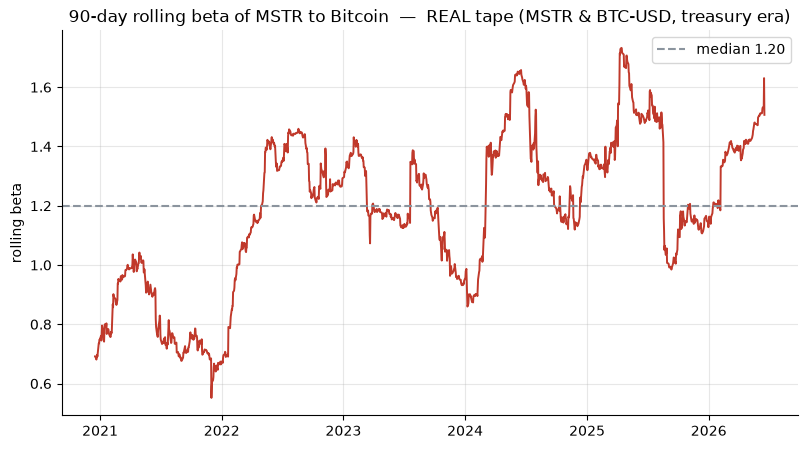

rolling beta range: 0.55 .. 1.73


In [3]:
rm = st.simple_returns(FRAME['mstr']); rb = st.simple_returns(FRAME['btc'])
b = pd.concat([rm, rb], axis=1).dropna(); b.columns = ['m','c']
roll = (b['m'].rolling(90).cov(b['c']) / b['c'].rolling(90).var()).dropna()
fig, ax = plt.subplots()
ax.plot(roll.index, roll.values, color=RED, lw=1.4)
ax.axhline(roll.median(), color=GREY, ls='--', label=f'median {roll.median():.2f}')
ax.set_title(f'90-day rolling beta of MSTR to Bitcoin  —  {BANNER}')
ax.set_ylabel('rolling beta'); ax.legend(); plt.show()
print(f'rolling beta range: {roll.min():.2f} .. {roll.max():.2f}')

### 4.2 The race + the bootstrap CI on the wrapper's edge

MSTR vs a levered-BTC replica at its own beta, net borrow, excess-of-cash Sharpe. The decisive object is the **block-bootstrap CI on the daily MSTR − replica difference**.

In [4]:
race = st.race_mstr_vs_proxy(FRAME, rf_daily=0.03/365, financing_bps_per_day=0.08/365*1e4)
lev = race['leverage']
proxy = st.levered_btc_proxy(FRAME, lev, 0.08/365*1e4)
idx = rm.index.intersection(rb.index).intersection(proxy.index)
diff = (rm.loc[idx] - proxy.loc[idx]).to_numpy()
lo, hi = st.block_bootstrap_ci(diff, block=20, n_boot=4000)
tab = pd.DataFrame({
    'CAGR %':   [race['mstr_cagr']*100, race['btc_cagr']*100, race['proxy_cagr']*100],
    'Sharpe':   [race['mstr_sharpe'], race['btc_sharpe'], race['proxy_sharpe']],
    'MaxDD %':  [race['mstr_mdd']*100, race['btc_mdd']*100, race['proxy_mdd']*100],
}, index=['MSTR', 'BTC 1x', f'levered replica {lev:.2f}x'])
print(tab.round(1))
print(f'\nMSTR - replica: {np.nanmean(diff)*1e4:+.1f} bps/day  '
      f'HAC t = {st.hac_tstat(diff):+.2f}  bootstrap 95% CI = [{lo*1e4:+.1f}, {hi*1e4:+.1f}] bps')

                       CAGR %  Sharpe  MaxDD %
MSTR                   70.900   1.000  -89.300
BTC 1x                 53.700   0.900  -76.600
levered replica 1.13x  55.100   0.900  -81.300

MSTR - replica: +11.0 bps/day  HAC t = +1.10  bootstrap 95% CI = [-8.6, +31.2] bps


> 💡 **In plain words:** the wrapper's edge over plain leverage has a confidence interval (**[-9, 31] bps/day** on the real tape) that **includes zero**. You cannot reject 'MSTR = its own leverage.' And MSTR's drawdown was *worse* than the replica's — the premium bought extra risk, not return.

### 4.3 The premium-timing null

Hold MSTR only when its price-premium is below median; one execution lag (signal at close of *t* → return of *t+1*), 5 bps one-way cost; vs always-hold.

In [5]:
tim = st.premium_timing(FRAME, cost_bps=5.0)
for k in ['always_cagr','timed_cagr','always_sharpe','timed_sharpe',
          'diff_mean_bps','diff_t','pct_in_market']:
    print(f'  {k:16s}: {tim[k]:+.3f}')
prem = st.nav_premium(FRAME)
print(f'\npremium proxy range: [{prem.min():+.2f}, {prem.max():+.2f}], std {prem.std():.2f}')

  always_cagr     : +0.709
  timed_cagr      : +0.677
  always_sharpe   : +1.033
  timed_sharpe    : +1.057
  diff_mean_bps   : -9.278
  diff_t          : -0.885
  pct_in_market   : +0.500

premium proxy range: [-0.99, +1.02], std 0.38


> 💡 **In plain words:** the premium swings enormously yet timing it returns **-9 bps/day at *t* = -0.88** — *negative* and insignificant on the real tape. A mean-reverting premium is a risk factor (Lee-Shleifer-Thaler), not a harvestable coupon.

### 4.4 The positive control — does the apparatus *work*?

A pipeline that finds nothing proves nothing unless it can find something when it's there. On the synthetic tape we plant a genuine alpha and confirm the **same** decomposition + race recovers it (and finds nothing on the null) — a machinery proof, **never** market evidence.

In [6]:
null_f, _  = data.synthetic_pair(n_days=2500, beta=1.8, alpha=0.0,    premium_vol=0.30, seed=324)
alpha_f, _ = data.synthetic_pair(n_days=2500, beta=1.8, alpha=0.0010, premium_vol=0.30, seed=324)
rows = []
for name, f in [('null  (no alpha)', null_f), ('planted alpha', alpha_f)]:
    d = st.beta_decomposition(f)
    rc = st.race_mstr_vs_proxy(f)
    rows.append({'tape': name, 'beta': d['beta'], 'alpha t': d['t_alpha'],
                 'race diff bps': rc['diff_mean_bps'], 'race diff t': rc['diff_t']})
ctrl = pd.DataFrame(rows).set_index('tape')
print(ctrl.round(2))
print('\nThe harness recovers a real edge ONLY when one is planted -> it is a faithful detector.')

                  beta  alpha t  race diff bps  race diff t
tape                                                       
null  (no alpha) 1.760    0.140          2.040        0.140
planted alpha    1.760    0.840         12.040        0.840

The harness recovers a real edge ONLY when one is planted -> it is a faithful detector.


## 5 · The verdict

- **Signal — None.** Treasury-era beta **1.13**, R² **50%**, residual alpha HAC *t* = **1.08** (below 2). MSTR is, statistically, levered Bitcoin plus noise.
- **Tradability — Mirage.** MSTR − levered-replica = **+11 bps/day**, bootstrap CI **[-9, 31]** (straddles zero), and a **worse drawdown** than the replica; premium timing is *t* = -0.88. The edge is leverage you can rent more cheaply.
- **Just leveraged Bitcoin? — Confirmed.**

## 6 · Could you trade it?

There is no cost at which 'prefer MSTR to Bitcoin' becomes attractive, because the failure isn't cost — it's **substitutability**. A 1.1× BTC position (or a 2× BTC ETF held part-size) replicates the upside with cheaper, transparent financing and a smaller drawdown, and without paying a **closed-end-fund premium that swings from rich to cheap on sentiment** (the GBTC +100% → −50% round-trip is the cautionary tale). The capacity question is moot: the product you'd be buying is leverage, and leverage on Bitcoin is a liquid, cheaper commodity.

## 7 · Going further

- **Model the convertibles.** MSTR's beta comes from convertible debt with option-like payoffs; a structural model would replace our constant-beta proxy and could reveal genuine *convexity* (distinct from alpha).
- **The treasury-company cross-section.** A growing universe of imitators — same decomposition, survivorship named (these are recent listings; go through the opt-in guard before any cross-section claim).
- **True mNAV.** Swap our price-proxy premium for reported coin-count / share-count to test premium-timing on the accounting premium.

Open a PR — break the null.